# K-Means Clustering

K-means is a suitable clustering method due to its simplicity, efficiency, and interpretability. 
- It is selected for its conceptual simplicity, speed and popularity (Turner et al., 2018), highlighting that it is both easy to implement and widely trusted. 
- In addition, it is a simple, fast algorithm that is computationally efficient (Turner et al., 2018), making it well-suited for large datasets such as galaxy surveys. 
- Furthermore, k-means produces interpretable results. In the research, the final centroids are cluster archetypes (Turner et al., 2018). This implies each cluster can be understood as a representative type of galaxy, which is particularly valuable for astronomical analysis.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# Astronomical Object Clustering Pipeline
## Unsupervised classification of Stars, Galaxies, and Quasars

**Dataset:** 10,000 spectroscopically confirmed observations  
**Task:** Cluster objects by photometric properties — *without* using class labels  
**Evaluation:** Post-hoc comparison of clusters to ground-truth labels (STAR, GALAXY, QSO)


## Part 0: Setup

In [2]:
from astral_pipeline import loader, features, cluster, evaluate, visualise
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
DATA_PATH = "../star-galaxy-quasar.csv"
df_raw = loader.load_raw(DATA_PATH)
print(f"[setup] Raw shape: {df_raw.shape}")

schema_report = loader.validate_schema(df_raw)
quality_report = loader.report_quality(df_raw)

print("[setup] Schema report:")
print(schema_report)

print("\n[setup] Quality report (high-level):")
print({
    "n_rows": quality_report.get("n_rows"),
    "n_cols": quality_report.get("n_cols"),
    "negative_redshift_count": quality_report.get("negative_redshift_count"),
})

[setup] Raw shape: (10000, 10)
[setup] Schema report:
{'is_valid': True, 'missing_columns': [], 'non_numeric_columns': [], 'n_rows': 10000, 'n_cols': 10}

[setup] Quality report (high-level):
{'n_rows': 10000, 'n_cols': 10, 'negative_redshift_count': 241}


In [3]:
df_raw.head(3)

,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327


## Part 1: Data cleaning

### Drop `ra` and `dec`

Right ascension and declination are sky coordinates — they tell us *where* an object is, not *what* it is. In a general photometric survey, all three object types are distributed across the sky with no systematic spatial segregation. These columns add noise to distance calculations.

In [4]:
X_raw, y, df_clean = loader.load_pipeline(
    DATA_PATH,
    drop_coords=True,
    keep_redshift=True,
    remove_invalid=True,
)

print("\n[setup] Pipeline outputs:")
print(f"  X_raw shape:   {X_raw.shape}")
print(f"  y shape:       {y.shape}")

print(f"  df_clean shape:{df_clean.shape}")
print(f"  X_raw columns: {list(X_raw.columns)}")
print(f"  y classes:\n{y.value_counts().to_string()}")


[loader] Removed 256 rows with sentinel/invalid values (2.56% of data).
[loader] Final dataset: 9744 rows, 6 features.
[loader] Class distribution:
class
GALAXY    8434
QSO        685
STAR       625

[setup] Pipeline outputs:
  X_raw shape:   (9744, 6)
  y shape:       (9744,)
  df_clean shape:(9744, 10)
  X_raw columns: ['u', 'g', 'r', 'i', 'z', 'redshift']
  y classes:
class
GALAXY    8434
QSO        685
STAR       625


### Outliers removed
Outliers were identified following these rules:  
1. For each band in u, g, r, i, z:
- value must be strictly between -50 and 50
- so values <= -50 or >= 50 are removed
2. redshift must be >= 0

In [5]:
X_raw.head(3)

,u,g,r,i,z,redshift
0,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934
1,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808
2,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327


In [6]:
df_clean.head(3)

,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327


## Part 2: EDA (Exploratory Data Analysis)

In [7]:
# CORRECT — build X_eda from features only, no y involved
X_eda = X_raw.copy()
X_eda["u-g"] = X_eda["u"] - X_eda["g"]
X_eda["g-r"] = X_eda["g"] - X_eda["r"]
X_eda["r-i"] = X_eda["r"] - X_eda["i"]
X_eda["i-z"] = X_eda["i"] - X_eda["z"]

In [8]:
# Structural bookkeeping — class counts reported for transparency only,
# not used in any downstream analytical decision
print("[Dataset] Class distribution (for transparency only — not used in pipeline):")
print(y.value_counts().to_string())
print(f"\n[Dataset] Total rows after cleaning: {len(X_eda)}")
print(f"[Dataset] Note: one class dominates (~{y.value_counts().iloc[0]/len(y)*100:.0f}% of rows).")
print("          Clustering algorithms optimising for compact equal-sized clusters")
print("          (e.g. K-Means) may be biased toward the majority group.")

[Dataset] Class distribution (for transparency only — not used in pipeline):
class
GALAXY    8434
QSO        685
STAR       625

[Dataset] Total rows after cleaning: 9744
[Dataset] Note: one class dominates (~87% of rows).
          Clustering algorithms optimising for compact equal-sized clusters
          (e.g. K-Means) may be biased toward the majority group.


In [8]:
print("[EDA] Features:", list(X_eda.columns))
print("\n[EDA] Numeric summary:")
print(X_eda.describe().T[["mean", "std", "min", "max"]].to_string())

print("\n[EDA] Redshift — skewness:", round(X_eda["redshift"].skew(), 3))
print("[EDA] Redshift — range:   ", round(X_eda["redshift"].min(), 4),
      "to", round(X_eda["redshift"].max(), 4))
print("[EDA] Note: large std and right-skewed distribution suggest")
print("      heterogeneous object types spanning a wide range of distances.")

[EDA] Features: ['u', 'g', 'r', 'i', 'z', 'redshift', 'u-g', 'g-r', 'r-i', 'i-z']

[EDA] Numeric summary:
               mean       std       min        max
u         19.907014  1.536770  11.96091  28.238530
g         18.273652  1.218813  12.37476  25.532540
r         17.399159  1.063988  12.29743  24.801930
i         16.991397  1.065531  12.18435  30.831510
z         16.709745  1.088634  11.80645  26.259070
redshift   0.193853  0.334260   0.00000   6.827977
u-g        1.633362  0.738189  -8.23566   8.175870
g-r        0.874493  0.475746  -6.68352   8.396770
r-i        0.407761  0.272133 -12.96309   7.161740
i-z        0.281652  0.252033  -5.64933  11.546050

[EDA] Redshift — skewness: 5.272
[EDA] Redshift — range:    0.0 to 6.828
[EDA] Note: large std and right-skewed distribution suggest
      heterogeneous object types spanning a wide range of distances.


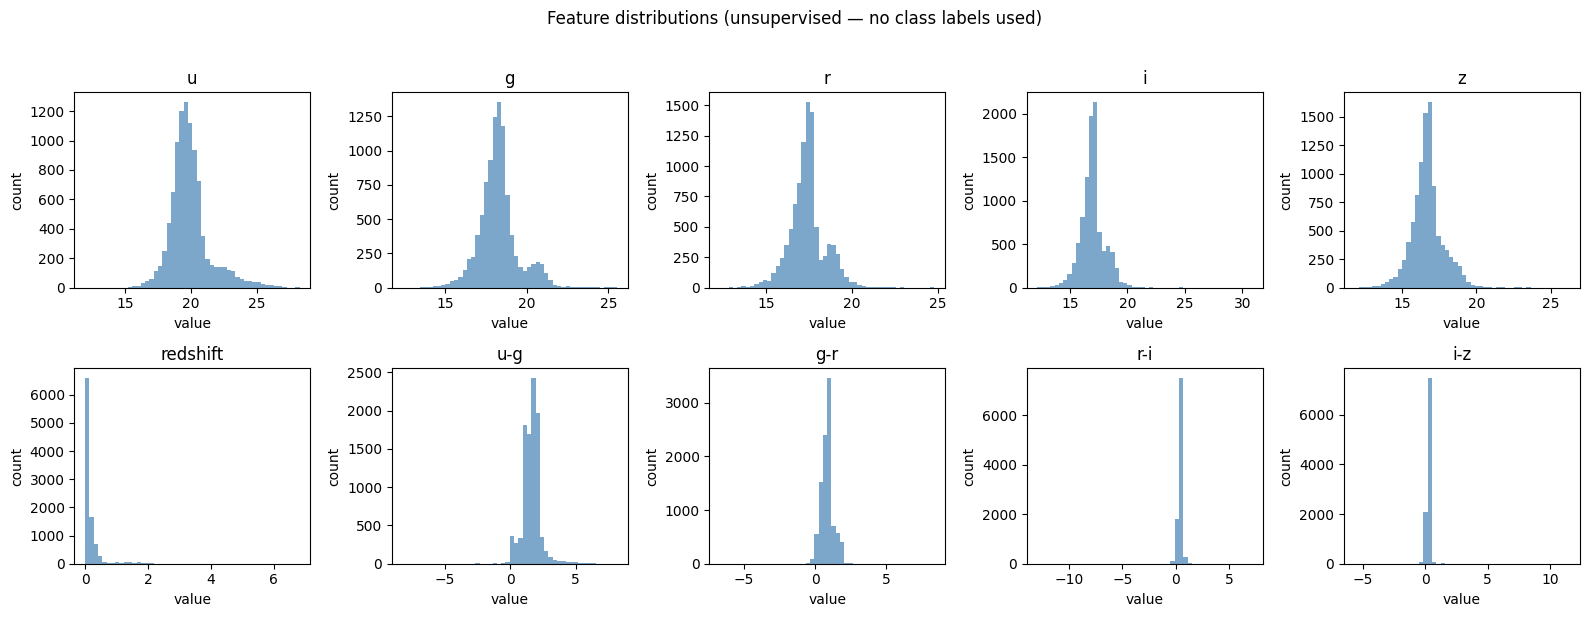

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.flat, X_eda.columns):
    ax.hist(X_eda[col], bins=50, color="steelblue", alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
fig.suptitle("Feature distributions (unsupervised — no class labels used)", y=1.02)
plt.tight_layout()
plt.show()

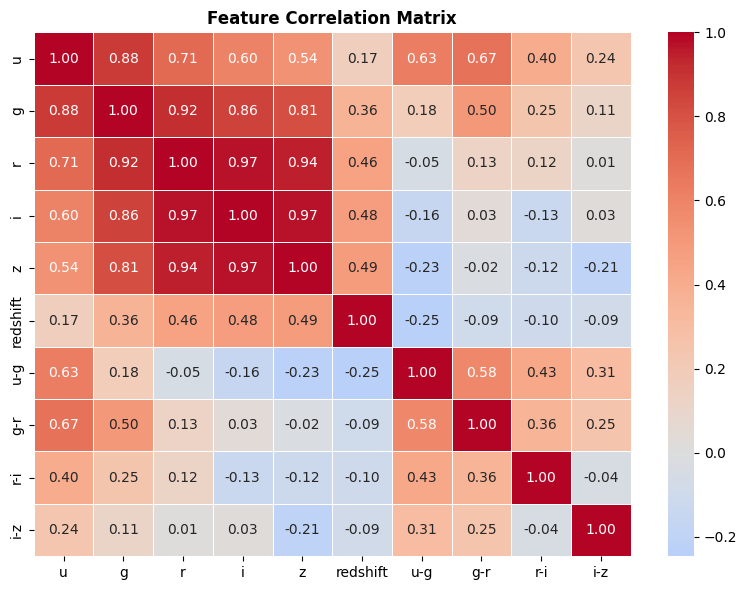

In [9]:
fig = visualise.plot_correlation_matrix(X_eda)
plt.show()

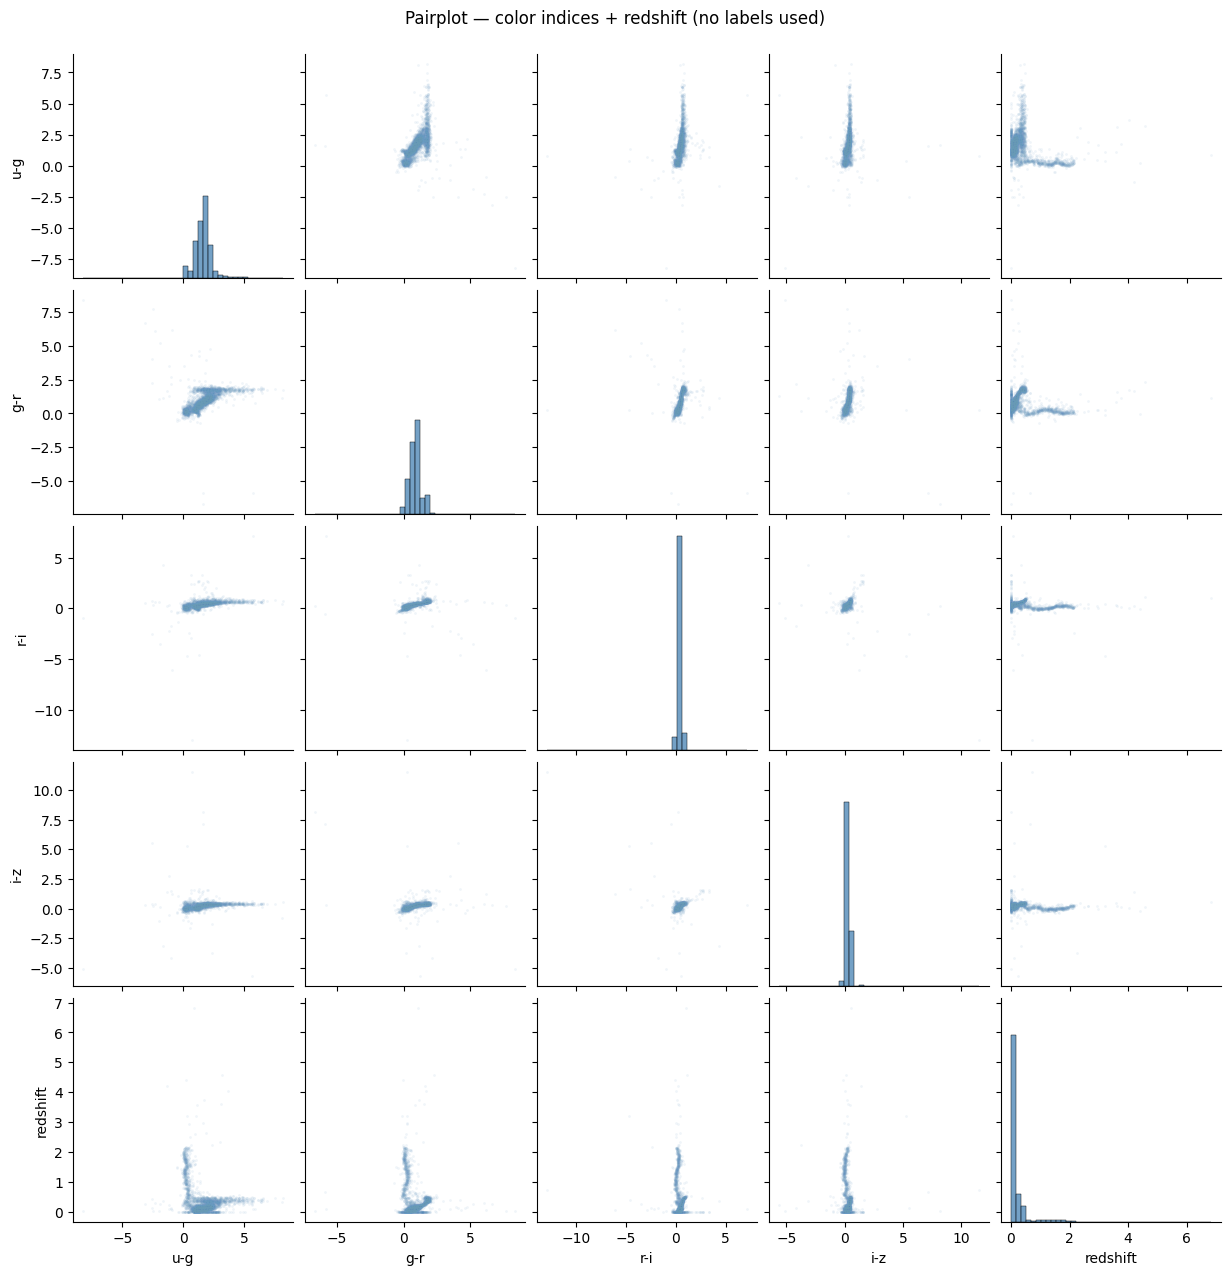

In [10]:
import seaborn as sns

pair_cols = ["u-g", "g-r", "r-i", "i-z", "redshift"]
sns.pairplot(
    X_eda[pair_cols],
    plot_kws={"alpha": 0.08, "s": 4, "color": "steelblue"},
    diag_kws={"color": "steelblue", "bins": 40}
)
plt.suptitle("Pairplot — color indices + redshift (no labels used)", y=1.02)
plt.show()

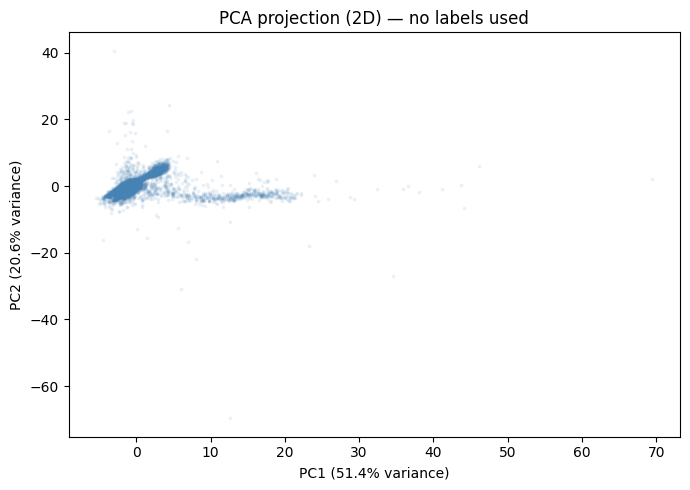

[EDA] PCA explained variance per component: [0.514 0.206]
[EDA] PCA loadings (PC1 and PC2):
            PC1    PC2
u         0.076  0.364
g         0.141  0.296
r         0.173  0.215
i         0.182  0.115
z         0.175  0.090
redshift  0.932 -0.069
u-g      -0.067  0.246
g-r      -0.020  0.267
r-i      -0.070  0.749
i-z      -0.043  0.116


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

X_scaled_eda = RobustScaler().fit_transform(X_eda)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_eda)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.08, s=3, color="steelblue")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA projection (2D) — no labels used")
plt.tight_layout()
plt.show()

print("[EDA] PCA explained variance per component:", pca.explained_variance_ratio_.round(3))
print("[EDA] PCA loadings (PC1 and PC2):")
print(pd.DataFrame(pca.components_.T, index=X_eda.columns, columns=["PC1", "PC2"]).round(3))

### Observations

1. **Strong dataset imbalance**: One object type accounts for ~87% of rows (see dataset
   overview above). Algorithms optimising for compact, equal-sized clusters may be biased
   toward the majority group and under-represent minority structures.

2. **Redshift is highly right-skewed**: The distribution has a large standard deviation
   relative to its mean and a long tail extending to ~6.8. This suggests the dataset spans
   a wide range of cosmic distances. Physically, different classes of astronomical object
   occupy different redshift regimes, so this feature likely carries strong discriminative
   structure — justified by photometric physics, not by inspecting labels.

3. **Color indices are more compact than raw bands**: The u-g, g-r, r-i, i-z columns have
   lower variance and less skew than the raw magnitude columns. This is consistent with the
   photometric motivation for using color indices: they encode spectral shape rather than
   absolute brightness, reducing distance-dependent brightness variation across objects.

4. **Raw bands are highly correlated**: The correlation matrix shows strong positive
   correlation among u, g, r, i, z. Including all five raw bands alongside their differences
   (Set C) risks redundancy — the added features may not contribute independent information
   beyond what Set B already captures.

5. **PCA suggests non-trivial structure**: The 2D PCA projection shows an elongated,
   non-spherical cloud with visible density variation rather than a single homogeneous blob.
   This motivates clustering — the data is unlikely to be drawn from one distribution.
   The PCA loadings identify which features dominate each component.

6. **Outlier/sentinel handling matters**: As noted in Part 1, invalid magnitude values and
   negative redshifts were removed prior to EDA. Leaving them in would distort variance
   estimates, skew the correlation matrix, and bias PCA components toward artefacts.

## Part 3: Feature Engineering

In [12]:
X_with_colors = features.add_color_indices(X_raw)
print("[FE] Adjacent color indices:", [c for c in X_with_colors.columns if "-" in c])

[FE] Adjacent color indices: ['u-g', 'g-r', 'r-i', 'i-z']


In [13]:
custom_pairs = [("u", "r"), ("g", "i"), ("r", "z")]
X_custom_diffs = features.add_custom_differences(X_with_colors, custom_pairs)
print("[FE] Skip-band differences added:", [f"{a}-{b}" for a, b in custom_pairs])

[FE] Skip-band differences added: ['u-r', 'g-i', 'r-z']


In [14]:
feature_sets = features.build_feature_sets(X_raw)

print("\n[FE] Standard sets:")
for name, df_set in feature_sets.items():
    print(f"  Set {name}: shape={df_set.shape}, columns={list(df_set.columns)}")

[features] Feature sets constructed:
  Set A: ['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: ['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: ['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']

[FE] Standard sets:
  Set A: shape=(9744, 6), columns=['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: shape=(9744, 5), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: shape=(9744, 10), columns=['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']


In [15]:
X_custom = features.make_feature_set(
    X_raw,
    include_bands=False,
    include_colors=True,
    include_redshift=True,
    extra_cols=[c for c in ["u-r", "g-i", "r-z"] if c in X_custom_diffs.columns],
)

for c in ["u-r", "g-i", "r-z"]:
    if c in X_custom_diffs.columns and c not in X_custom.columns:
        X_custom[c] = X_custom_diffs[c].values

print("\n[FE] Custom set:")
print(f"  shape={X_custom.shape}")
print(f"  columns={list(X_custom.columns)}")


[FE] Custom set:
  shape=(9744, 8)
  columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift', 'u-r', 'g-i', 'r-z']


In [16]:
X_set_D = pd.DataFrame(index=X_raw.index)

# Adjacent color indices (same as Set B)
X_set_D["u-g"] = X_raw["u"] - X_raw["g"]
X_set_D["g-r"] = X_raw["g"] - X_raw["r"]
X_set_D["r-i"] = X_raw["r"] - X_raw["i"]
X_set_D["i-z"] = X_raw["i"] - X_raw["z"]

# Wide-baseline colors: capture full optical spectral slope
X_set_D["u-z"] = X_raw["u"] - X_raw["z"]
X_set_D["g-z"] = X_raw["g"] - X_raw["z"]

# UV spectral curvature: (u-g) - (g-r)
# Measures deviation from a linear spectral slope in the UV/optical
X_set_D["uv_excess"] = (X_raw["u"] - X_raw["g"]) - (X_raw["g"] - X_raw["r"])

# r-i squared: nonlinear amplification of the color that dominated PC2 (loading=0.749)
X_set_D["r_i_sq"] = (X_raw["r"] - X_raw["i"]) ** 2

# Log redshift: compresses heavy right tail observed in EDA (skew, max~6.8)
X_set_D["redshift_log"] = np.log1p(X_raw["redshift"])

print("[FE] Set D columns:", list(X_set_D.columns))
print("[FE] Set D shape:  ", X_set_D.shape)

[FE] Set D columns: ['u-g', 'g-r', 'r-i', 'i-z', 'u-z', 'g-z', 'uv_excess', 'r_i_sq', 'redshift_log']
[FE] Set D shape:   (9744, 9)


In [17]:
candidate_feature_sets = {
    "A":      feature_sets["A"],
    "B":      feature_sets["B"],
    "C":      feature_sets["C"],
    "CUSTOM": X_custom,
    "D":      X_set_D,
}

print("[FE] All feature sets:")
for name, df_set in candidate_feature_sets.items():
    print(f"  Set {name}: shape={df_set.shape}, columns={list(df_set.columns)}")

[FE] All feature sets:
  Set A: shape=(9744, 6), columns=['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: shape=(9744, 5), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: shape=(9744, 10), columns=['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set CUSTOM: shape=(9744, 8), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift', 'u-r', 'g-i', 'r-z']
  Set D: shape=(9744, 9), columns=['u-g', 'g-r', 'r-i', 'i-z', 'u-z', 'g-z', 'uv_excess', 'r_i_sq', 'redshift_log']


In [18]:
print("[FE] Sanity check — NaNs and Infs:")
for name, df_set in candidate_feature_sets.items():
    n_nan = df_set.isna().sum().sum()
    n_inf = np.isinf(df_set.values).sum()
    status = "OK" if (n_nan == 0 and n_inf == 0) else "*** PROBLEM ***"
    print(f"  Set {name}: NaNs={n_nan}, Infs={n_inf}  [{status}]")

[FE] Sanity check — NaNs and Infs:
  Set A: NaNs=0, Infs=0  [OK]
  Set B: NaNs=0, Infs=0  [OK]
  Set C: NaNs=0, Infs=0  [OK]
  Set CUSTOM: NaNs=0, Infs=0  [OK]
  Set D: NaNs=0, Infs=0  [OK]


### Feature engineering summary

Starting from the five raw photometric bands (u, g, r, i, z) and redshift,
we constructed five candidate feature sets:

- **Set A** — raw bands + redshift. Baseline; bands are highly correlated
  (confirmed by correlation matrix in EDA) so this set carries redundancy.

- **Set B** — adjacent color indices (u-g, g-r, r-i, i-z) + redshift.
  Encodes spectral shape independent of absolute brightness. Motivated by
  the photometric principle that color differences cancel distance-dependent
  dimming.

- **Set C** — raw bands + color indices + redshift. Combined set; risks
  redundancy since color indices are linear combinations of the bands.

- **Set CUSTOM** — adjacent + skip-band color indices (u-r, g-i, r-z) +
  redshift. Wider spectral differences than Set B but no raw bands.

- **Set D** — new set motivated by EDA findings:
  - `u-z`, `g-z`: wide-baseline colors capturing the full optical spectral
    slope, not just adjacent-band steps.
  - `uv_excess = (u-g) - (g-r)`: spectral curvature in the UV/optical,
    a second-order color sensitive to UV-excess objects.
  - `r_i_sq = (r-i)^2`: nonlinear amplification of the near-IR color that
    dominated PC2 in the PCA (loading = 0.749).
  - `redshift_log = log1p(redshift)`: log-transforms the heavily right-skewed
    redshift distribution (skewness observed in EDA) for better distance
    metric behaviour.

All features are computed before scaling and before any clustering step.
No label information was used in any feature engineering decision.

## Part 4: Preprocessing / Scaling

Before clustering, each feature set was scaled to prevent variables with larger
numeric ranges from dominating distance-based methods.

RobustScaler is used as the default because it scales by the interquartile range
rather than the mean/std, making it less sensitive to the residual extreme values
that remain after cleaning. StandardScaler and MinMaxScaler are kept as
configurable alternatives.

Scaling is applied separately to each feature set and stored in `prepared` for
use in all downstream clustering steps.

In [19]:
DEFAULT_SCALER = "robust"

# Scale the standard sets A, B, C, CUSTOM via pipeline function
prepared = features.prepare_all_sets(candidate_feature_sets, scaler_kind=DEFAULT_SCALER)

print(f"[Scaling] Using scaler: {DEFAULT_SCALER}")
print("[Scaling] Sets scaled by pipeline:")
for name, d in prepared.items():
    print(f"  Set {name}: shape={d['X_scaled'].shape}, columns={d['columns']}")

[features] Set A scaled — shape: (9744, 6)
[features] Set B scaled — shape: (9744, 5)
[features] Set C scaled — shape: (9744, 10)
[features] Set CUSTOM scaled — shape: (9744, 8)
[features] Set D scaled — shape: (9744, 9)
[Scaling] Using scaler: robust
[Scaling] Sets scaled by pipeline:
  Set A: shape=(9744, 6), columns=['u', 'g', 'r', 'i', 'z', 'redshift']
  Set B: shape=(9744, 5), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set C: shape=(9744, 10), columns=['u', 'g', 'r', 'i', 'z', 'u-g', 'g-r', 'r-i', 'i-z', 'redshift']
  Set CUSTOM: shape=(9744, 8), columns=['u-g', 'g-r', 'r-i', 'i-z', 'redshift', 'u-r', 'g-i', 'r-z']
  Set D: shape=(9744, 9), columns=['u-g', 'g-r', 'r-i', 'i-z', 'u-z', 'g-z', 'uv_excess', 'r_i_sq', 'redshift_log']


In [20]:
from sklearn.preprocessing import RobustScaler

# Check whether prepare_all_sets handled Set D
if "D" not in prepared:
    print("[Scaling] Set D was not scaled by pipeline — adding manually")
    scaler_D = RobustScaler()
    X_D_scaled = scaler_D.fit_transform(X_set_D)
    prepared["D"] = {
        "X_scaled": X_D_scaled,
        "columns":  list(X_set_D.columns),
        "scaler":   scaler_D,
    }
else:
    print("[Scaling] Set D already present from pipeline")

# Final verification — all 5 sets must be present
expected = {"A", "B", "C", "CUSTOM", "D"}
missing  = expected - set(prepared.keys())
if missing:
    raise ValueError(f"[Scaling] Missing sets after scaling: {missing}")

print("\n[Scaling] Final prepared sets:")
for name, d in prepared.items():
    print(f"  Set {name}: shape={d['X_scaled'].shape}, n_features={len(d['columns'])}")

[Scaling] Set D already present from pipeline

[Scaling] Final prepared sets:
  Set A: shape=(9744, 6), n_features=6
  Set B: shape=(9744, 5), n_features=5
  Set C: shape=(9744, 10), n_features=10
  Set CUSTOM: shape=(9744, 8), n_features=8
  Set D: shape=(9744, 9), n_features=9


In [21]:
print("[Scaling] Sanity check on scaled values:")
for name, d in prepared.items():
    X_s = d["X_scaled"]
    n_nan = np.isnan(X_s).sum()
    n_inf = np.isinf(X_s).sum()
    median = np.median(X_s)
    status = "OK" if (n_nan == 0 and n_inf == 0) else "*** PROBLEM ***"
    print(f"  Set {name}: NaNs={n_nan}, Infs={n_inf}, median={median:.4f}  [{status}]")

[Scaling] Sanity check on scaled values:
  Set A: NaNs=0, Infs=0, median=0.0000  [OK]
  Set B: NaNs=0, Infs=0, median=0.0000  [OK]
  Set C: NaNs=0, Infs=0, median=0.0000  [OK]
  Set CUSTOM: NaNs=0, Infs=0, median=0.0000  [OK]
  Set D: NaNs=0, Infs=0, median=0.0000  [OK]


### K-Means

K-means is a suitable clustering method due to its simplicity, efficiency, and interpretability. 
- It is selected for its conceptual simplicity, speed and popularity (Turner et al., 2018), highlighting that it is both easy to implement and widely trusted. 
- In addition, it is a simple, fast algorithm that is computationally efficient (Turner et al., 2018), making it well-suited for large datasets such as galaxy surveys. 
- Furthermore, k-means produces interpretable results. In the research, the final centroids are cluster archetypes (Turner et al., 2018). This implies each cluster can be understood as a representative type of galaxy, which is particularly valuable for astronomical analysis.

#### Feature Set Justification

- As shown by the correlation matrix earlier, raw magnitudes (Set A) are highly correlated and brightness dependent. Hence, colour indices (Set B) may be physically better motivated and cancel distance-dependent dimming.
- Set C which has both raw and colour indices adds redundancy.
- Set D introduced non-linear transforms which distorts the feature space that break K-means, yielding degenerate solutions.

Given astronomical context and empirical evidence from our EDA, we focus on Set A and Set B as our primary K-Means candidates.

#### Choice of K - Set A

- Elbow: Measures compactness (how tight clusters are)
- Sihouette score: Measures separation + cohesion (Compares how close points are to their own cluster vs other clusters)

Elbow alone is often ambiguous as there is no clear elbow, while sihouette alone can be misleading as it favours simpler structures. Hence, combining them gives a more robust decision.

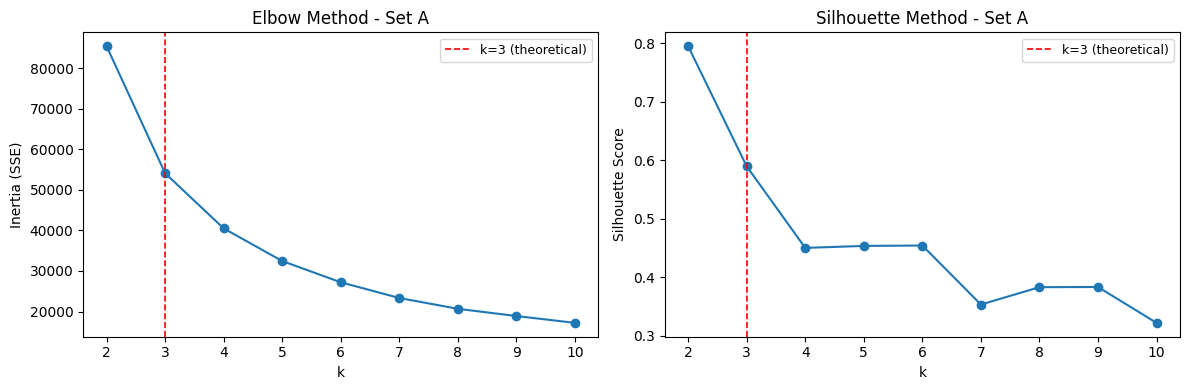

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(prepared["A"]["X_scaled"])
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(prepared["A"]["X_scaled"], labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(k_range, inertias, marker='o')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow Method - Set A")
axes[0].legend(fontsize=9)

# Silhouette plot
axes[1].plot(k_range, silhouettes, marker='o')
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Method - Set A")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Interpretation of results:

Elbow:
- No clean elbow: Inertia drops continuously and fairly smoothly from k = 2 to k = 10. The theoretical k=3 line sits at a relatively clear bend which gives moderate support for k = 3. Beyond k = 3, the gains diminish gradually.

Silhouette:
- The silhouette strongly prefers k=2, with k=3 as a secondary candidate. 

#### Cluster Stability for Optimal K - Set A

STACO measures solution stability. We ran 100 random initialisations to check how consistently K-Means produce the same clustering.  
- A Cramér's V near 1.0 means every random start converges to the same solution. 
- A lower score means different starts produce meaningfully different clusterings.

Clustering...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.
Labels saved.
Measuring stabilities...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.

staco shape: (900, 3)  (columns: stability, compactness, k)


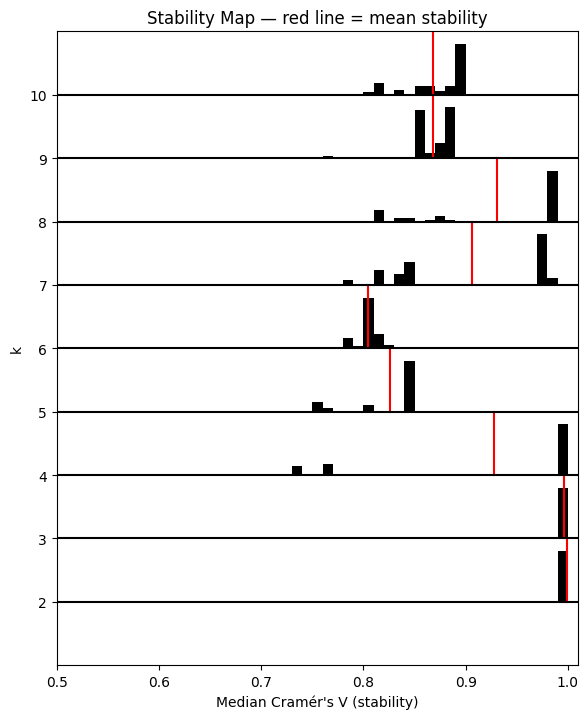

In [24]:
# Additional imports required by stacopy
import scipy.stats
import sklearn.metrics
import joblib
import os
import glob

def V(matrix):
    """
    Calculates Cramer's V index of association from a confusion matrix.
    Cramer's V ranges from 0 (no association) to 1 (perfect agreement).
    Use sklearn.metrics.confusion_matrix to set up a confusion matrix.
    """
    chi = scipy.stats.chi2_contingency(matrix)[0]
    n = matrix.sum()
    return np.sqrt(chi / (n * (min(matrix.shape) - 1)))


def STACOK(data, k):
    """
    Runs k-means once for input data at input k.
    Returns labels (array) and compactness (inertia).
    """
    kmrun = KMeans(
        n_clusters=k,
        max_iter=data.shape[0],
        n_init=1,
        tol=0,
        init='k-means++',
        random_state=None
    ).fit(data)
    return kmrun.predict(data), kmrun.inertia_


def STACOV(lbls, i):
    """
    Calculates median Cramer's V for the ith solution w.r.t. all other
    solutions at the same k. Higher = more stable/consistent.

    Args:
        lbls: (n_obs, init) array of cluster labels for all solutions at one k
        i:    index of the solution to evaluate
    Returns:
        Median Cramer's V across all pairwise comparisons
    """
    lbls_others = np.delete(lbls, i, axis=1)
    cvind = np.zeros((lbls_others.shape[1], 1))
    for q in range(lbls_others.shape[1]):
        cvind[q, 0] = V(sklearn.metrics.confusion_matrix(lbls[:, i], lbls_others[:, q]))
    return np.median(cvind)


def STACO(data, k=range(2, 11), init=100, save_lbls=False):
    """
    Runs stacopy: calculates stabilities and compactnesses for `init` solutions
    at each value of k.

    Args:
        data:      (n_obs, n_features) array — clustering features only,
                   no IDs or flags. Data should already be scaled/normalised.
        k:         iterable of k values to evaluate (default: range(2, 11))
        init:      number of k-means initialisations per k (default: 100)
        save_lbls: if True, saves label arrays to 'lbls_k{k}.txt' files

    Returns:
        (init*len(k), 3) array with columns:
            [0] stability  — median Cramer's V
            [1] compactness — k-means inertia (phi)
            [2] k           — value of k
    """
    obs, feats = data.shape
    nk = len(k)
    k = list(k)

    lbls = np.zeros((obs, init, nk))
    phi  = np.zeros((init, nk))

    print("Clustering...")
    for j in range(nk):
        print(f"  k = {k[j]}")
        l, p = zip(*joblib.Parallel(n_jobs=-1, mmap_mode='w+')(
            joblib.delayed(STACOK)(data, k[j]) for i in range(init)
        ))
        lbls[:, :, j] = np.transpose(np.array(l))
        phi[:, j]     = np.transpose(np.array(p))
    print("Done.")

    if save_lbls:
        for j in range(nk):
            np.savetxt(f'lbls_k{k[j]}.txt', lbls[:, :, j], delimiter=',')
        print("Labels saved.")

    cvmed = np.zeros((init, nk))

    print("Measuring stabilities...")
    for j in range(nk):
        print(f"  k = {k[j]}")
        cvmed[:, j] = joblib.Parallel(n_jobs=-1, mmap_mode='w+')(
            joblib.delayed(STACOV)(lbls[:, :, j], i) for i in range(init)
        )
    print("Done.")

    cvmed = cvmed.flatten('F').reshape(-1, 1)
    phi   = phi.flatten('F').reshape(-1, 1)
    k_arr = (np.ones((init, 1)) * k).flatten('F').reshape(-1, 1)

    return np.hstack((cvmed, phi, k_arr))

# Run Stacopy on data
k    = range(2, 11)  # candidate k values to evaluate
init = 100            # number of k-means runs per k (use 100 for final analysis)

data = np.array(prepared["A"]["X_scaled"])  # ensure numpy array

lbls_dict = {}  # store labels in memory instead of disk

if __name__ == '__main__':
    staco = STACO(data, k=k, init=init, save_lbls=True)  # let it save temporarily

    # Read all saved label files into memory, then delete them
    for ki in k:
        fname = f'lbls_k{ki}.txt'
        if os.path.exists(fname):
            lbls_dict[ki] = np.genfromtxt(fname, delimiter=',')
            os.remove(fname)  # delete after reading

    # Also clean up staco results file
    if os.path.exists('staco_results.txt'):
        staco = np.genfromtxt('staco_results.txt', delimiter=',')
        os.remove('staco_results.txt')

    print(f"\nstaco shape: {staco.shape}  (columns: stability, compactness, k)")

# Plot stability map
fig, ax = plt.subplots(figsize=(6, 0.7 * len(k) + 1))

for i in k:
    cvs = staco[staco[:, 2] == i, 0].reshape(-1, 1)

    hist, bins = np.histogram(cvs, bins=np.arange(0.0, 1.01, 0.01))
    hist = (hist.astype(float) / float(max(hist))) * 0.8

    ax.plot([0.0, 1.01], [i, i], c='k', ls='-', lw=1.5, zorder=3)
    ax.bar(bins[1:] - 0.005, hist, width=0.01, bottom=i, color='k')
    ax.plot([np.mean(cvs), np.mean(cvs)], [i, i + 1], 'r-', lw=1.5)

ax.set(
    yticks=list(k),
    xlim=(0.5, 1.01),
    ylim=(min(k) - 1, max(k) + 1),
    xlabel='Median Cramér\'s V (stability)',
    ylabel='k'
)
ax.set_title('Stability Map — red line = mean stability')
plt.tight_layout()
plt.show()

The STACO stability analysis indicates k=2 and k = 3 results in the most stable solutions, with a median Cramer's V of almost 1.0

Hence, we will further investigate the following choices of k for Set A:

- k=2: Dominant signal. Both silhouette and stability agree, likely reflecting a stars vs. extragalactic split rather than the full QSO/star/galaxy separation.
- k=3: Physical prior that is worth investigating

### K-Means Evaluation (K=2, K=3) - Set A

In [25]:
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, silhouette_samples,
                             adjusted_rand_score, normalized_mutual_info_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# ── 0. Setup ──────────────────────────────────────────────────────────────────
le     = LabelEncoder()
y_true = le.fit_transform(y)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(prepared['A']['X_scaled'])
ev   = pca.explained_variance_ratio_

class_colors    = {"GALAXY": "#378ADD", "QSO": "#EF9F27", "STAR": "#1D9E75"}
cluster_colors  = ["#E24B4A", "#378ADD", "#1D9E75", "#EF9F27"]
k_values        = [2, 3]

# ── 1. Fit, evaluate, and store results for each k ───────────────────────────
results = {}

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(prepared['A']['X_scaled'])

    sil = silhouette_score(prepared['A']['X_scaled'], labels)
    db  = davies_bouldin_score(prepared['A']['X_scaled'], labels)
    ch  = calinski_harabasz_score(prepared['A']['X_scaled'], labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    ct          = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["true class"])
    ct.columns  = le.classes_
    sil_vals    = silhouette_samples(prepared['A']['X_scaled'], labels)

    results[k] = dict(labels=labels, sil=sil, db=db, ch=ch,
                      inertia=km.inertia_, ari=ari, nmi=nmi,
                      ct=ct, sil_vals=sil_vals)

# ── 2. Summary metrics table ──────────────────────────────────────────────────
print(f"{'k':<4} {'Silhouette':>10} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Inertia':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 75)
for k in k_values:
    r = results[k]
    print(f"{k:<4} {r['sil']:>10.4f} {r['db']:>15.4f} {r['ch']:>12.2f} {r['inertia']:>12.2f} {r['ari']:>8.4f} {r['nmi']:>8.4f}")

# ── 3. Crosstab and per-cluster purity for each k ────────────────────────────
for k in k_values:
    r  = results[k]
    ct = r["ct"]
    print(f"\n{'='*50}")
    print(f"k = {k}  |  Cluster × True Class")
    print('='*50)
    print(ct.to_string())
    print()
    for cl in np.unique(r["labels"]):
        dominant       = ct.loc[cl].idxmax()
        cluster_purity = ct.loc[cl].max() / ct.loc[cl].sum()
        n              = (r["labels"] == cl).sum()
        print(f"  Cluster {cl} → {dominant:8s}  ({cluster_purity*100:.1f}% pure, n={n})")

k    Silhouette  Davies-Bouldin   Calinski-H      Inertia      ARI      NMI
---------------------------------------------------------------------------
2        0.7953          0.4181     11685.87     85405.86   0.4246   0.3860
3        0.5893          0.6621     12047.49     54080.85   0.3216   0.2753

k = 2  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          8428  261   625
1             6  424     0

  Cluster 0 → GALAXY    (90.5% pure, n=9314)
  Cluster 1 → QSO       (98.6% pure, n=430)

k = 3  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          7360   81   522
1          1074  221   103
2             0  383     0

  Cluster 0 → GALAXY    (92.4% pure, n=7963)
  Cluster 1 → GALAXY    (76.8% pure, n=1398)
  Cluster 2 → QSO       (100.0% pure, n=383)


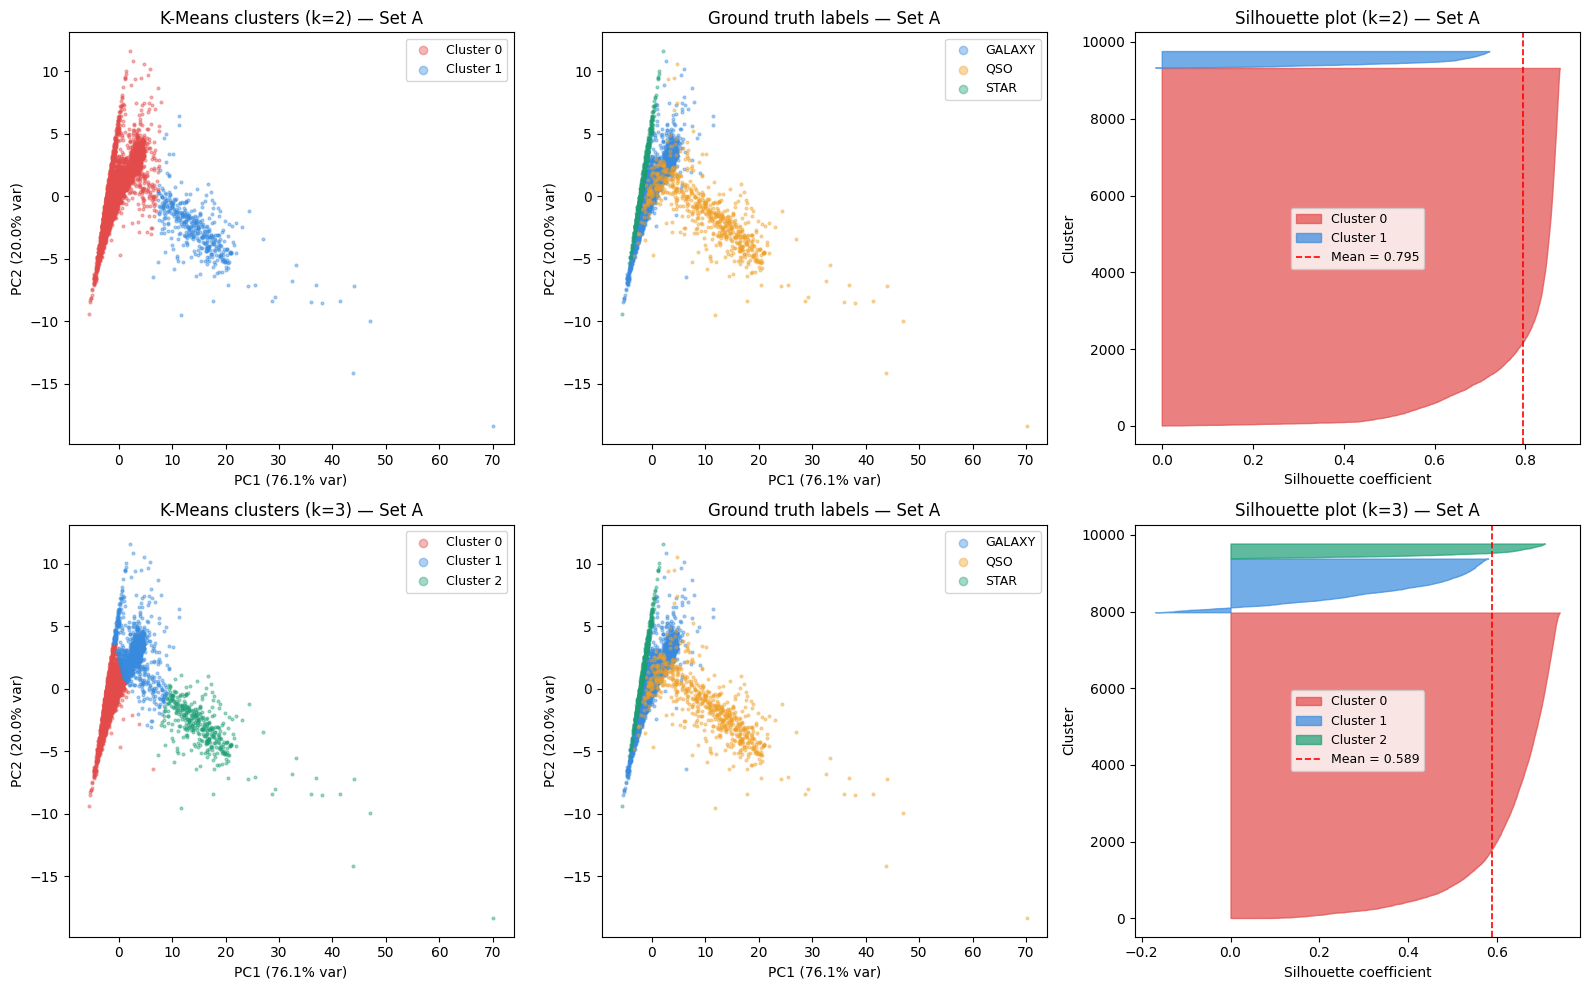

In [27]:
# ── 4. Plots: one row per k ───────────────────────────────────────────────────
fig, axes = plt.subplots(len(k_values), 3, figsize=(16, 5 * len(k_values)))

for row, k in enumerate(k_values):
    r      = results[k]
    labels = r["labels"]
    cols   = cluster_colors[:k]

    # Panel 1: cluster assignments
    ax = axes[row, 0]
    for i, cl in enumerate(np.unique(labels)):
        mask = labels == cl
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=cols[i], label=f"Cluster {cl}")
    ax.set_title(f"K-Means clusters (k={k}) — Set A")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

    # Panel 2: ground truth (same every row but useful for direct comparison)
    ax = axes[row, 1]
    for cls_name, col in class_colors.items():
        mask = y == cls_name
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=col, label=cls_name)
    ax.set_title(f"Ground truth labels — Set A")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

    # Panel 3: silhouette plot
    ax      = axes[row, 2]
    y_lower = 10
    for i, cl in enumerate(np.unique(labels)):
        cl_sil  = np.sort(r["sil_vals"][labels == cl])
        y_upper = y_lower + cl_sil.shape[0]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                         alpha=0.7, color=cols[i], label=f"Cluster {cl}")
        y_lower = y_upper + 10
    ax.axvline(x=r["sil"], color="red", linestyle="--", linewidth=1.2,
               label=f"Mean = {r['sil']:.3f}")
    ax.set_title(f"Silhouette plot (k={k}) — Set A")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Set A Conclusions

k=2: QSO vs. Everything
- The split is QSO vs. everything else, with all 625 stars are absorbed into the galaxy cluster (Cluster 0, 90.5% pure). 
- Metrics are strong, but the clustering is physically uninformative for a three-class problem. 
- The PCA structure forms a broad triangular/fan shape, with PC1 capturing 76.1% of variance, suggesting the feature set compresses variance efficiently into a dominant axis that separates QSOs cleanly.

k=3: Third cluster splits galaxies, not stars
- The third cluster does not isolate stars. Instead k=3, splits the galaxy population into two subgroups while Cluster 2 captures QSOs at 100% purity. The 625 stars are distributed across Clusters 0 and 1 with no dedicated star cluster emerging. 
- The silhouette plot shows Cluster 1 with a wide spread of low values, confirming this is a geometrically forced split rather than a natural boundary, while the ARI of 0.322 indicates only modest alignment with true labels.

K-Means finds two natural structures in this feature set: QSOs and a broad non-QSO population. Stars and galaxies occupy overlapping regions in PCA space and cannot be separated by K-Means. Recovering all three physical classes will require either additional discriminating features or a different algorithm better suited to overlapping, non-spherical cluster geometries.

#### Choice of K - Set B

In [30]:
# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------
from pathlib import Path
SCALED_FEATURE_PATH = Path("../Set_D.csv")
RAW_LABEL_PATH = Path("../star-galaxy-quasar.csv")

FEATURE_COLS = ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']
TARGET_COL = "class"

# -------------------------------------------------------------------
# Load the team's scaled feature table
# -------------------------------------------------------------------
scaled_df = pd.read_csv(SCALED_FEATURE_PATH)

missing_features = [c for c in FEATURE_COLS if c not in scaled_df.columns]
if missing_features:
    raise ValueError(
        f"Missing expected feature columns in {SCALED_FEATURE_PATH}: {missing_features}"
    )

Set_B = scaled_df[FEATURE_COLS].copy()

if TARGET_COL in scaled_df.columns:
    y = scaled_df[TARGET_COL].copy()
else:
    raw_labels = pd.read_csv(RAW_LABEL_PATH, skiprows=1)
    if TARGET_COL not in raw_labels.columns:
        raise ValueError(f"Could not find '{TARGET_COL}' in {RAW_LABEL_PATH}")
    if len(raw_labels) != len(scaled_df):
        raise ValueError(
            "Scaled feature table and raw label table have different row counts. "
            "Please verify row alignment before proceeding."
        )
    y = raw_labels[TARGET_COL].copy()

print("Feature matrix shape:", Set_B.shape)
print("Feature columns:", FEATURE_COLS)
print("\nClass distribution:")
print(y.value_counts(dropna=False))
Set_B.head()

Feature matrix shape: (9744, 5)
Feature columns: ['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']

Class distribution:
class
GALAXY    8434
QSO        685
STAR       625
Name: count, dtype: int64


,u-g,g-r,r-i,i-z,redshift_log
0,0.282411,0.199434,0.172105,0.112554,-0.129219
1,0.082362,0.183747,0.894299,0.214554,-0.423912
2,-0.312555,-0.067643,-0.071414,0.073737,-0.203070
3,0.397669,0.144856,0.245255,0.254769,-0.171899
4,-0.265413,-0.435137,-0.089880,-0.786944,-0.273773


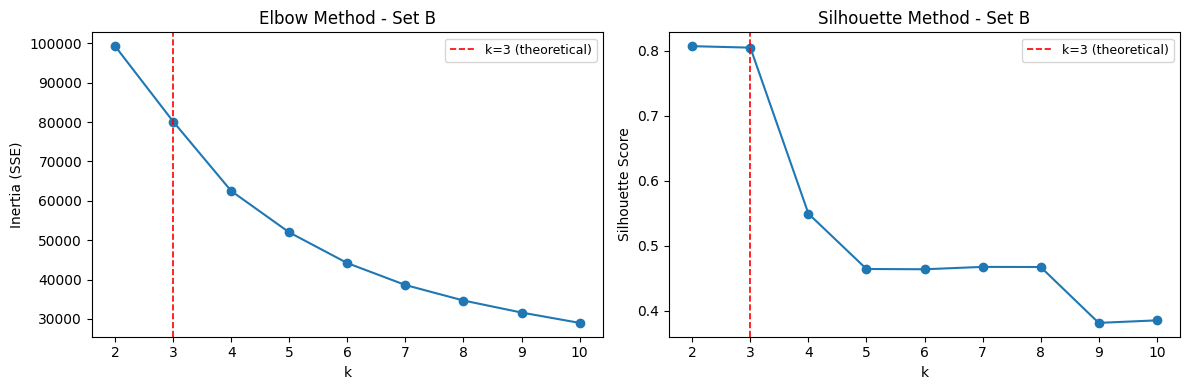

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Set_B)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(prepared["B"]["X_scaled"], labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(k_range, inertias, marker='o')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow Method - Set B")
axes[0].legend(fontsize=9)

# Silhouette plot
axes[1].plot(k_range, silhouettes, marker='o')
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Method - Set B")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Elbow:
- Set B's curve is noticeably more gradual than Set A's. The inertia values are also substantially higher across all k (starting at ~118k vs Set A's ~85k), indicating the data points are more spread out or less tightly grouped around centroids. This suggests Set B's feature space produces less compact clusters.

Silhouette:
- k=2 is slightly higher in Set B, while K=3 is lower in Set B. 

Set B may produce a sharper two-cluster solution but a weaker three-cluster one. The elbow is less defined and inertia is higher throughout, suggesting a feature set that separates QSOs well but does a poorer job of resolving finer structure within the non-QSO population.

#### Cluster Stability to choose Optimal K - SET B

Clustering...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.
Labels saved.
Measuring stabilities...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.

staco shape: (900, 3)  (columns: stability, compactness, k)


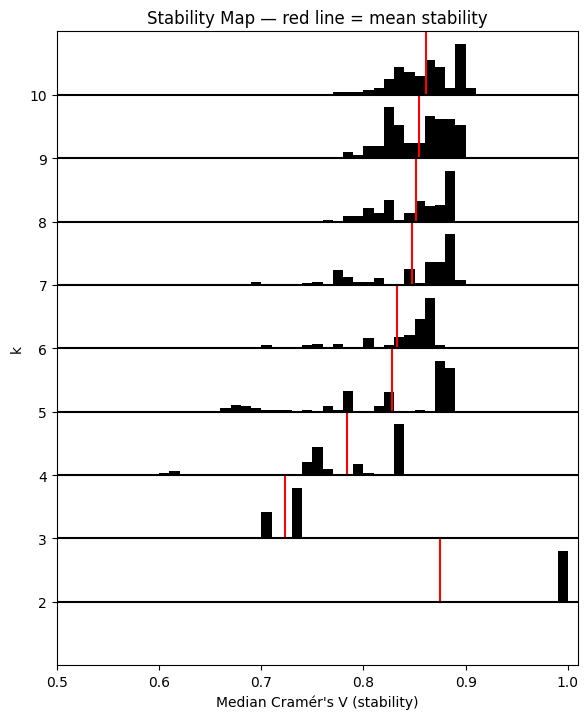

In [32]:
# Run Stacopy on data
k    = range(2, 11)  # candidate k values to evaluate
init = 100            # number of k-means runs per k (use 100 for final analysis)

data = np.array(Set_B)  # ensure numpy array

lbls_dict = {}  # store labels in memory instead of disk

if __name__ == '__main__':
    staco = STACO(data, k=k, init=init, save_lbls=True)  # let it save temporarily

    # Read all saved label files into memory, then delete them
    for ki in k:
        fname = f'lbls_k{ki}.txt'
        if os.path.exists(fname):
            lbls_dict[ki] = np.genfromtxt(fname, delimiter=',')
            os.remove(fname)  # delete after reading

    # Also clean up staco results file
    if os.path.exists('staco_results.txt'):
        staco = np.genfromtxt('staco_results.txt', delimiter=',')
        os.remove('staco_results.txt')

    print(f"\nstaco shape: {staco.shape}  (columns: stability, compactness, k)")

# Plot stability map
fig, ax = plt.subplots(figsize=(6, 0.7 * len(k) + 1))

for i in k:
    cvs = staco[staco[:, 2] == i, 0].reshape(-1, 1)

    hist, bins = np.histogram(cvs, bins=np.arange(0.0, 1.01, 0.01))
    hist = (hist.astype(float) / float(max(hist))) * 0.8

    ax.plot([0.0, 1.01], [i, i], c='k', ls='-', lw=1.5, zorder=3)
    ax.bar(bins[1:] - 0.005, hist, width=0.01, bottom=i, color='k')
    ax.plot([np.mean(cvs), np.mean(cvs)], [i, i + 1], 'r-', lw=1.5)

ax.set(
    yticks=list(k),
    xlim=(0.5, 1.01),
    ylim=(min(k) - 1, max(k) + 1),
    xlabel='Median Cramér\'s V (stability)',
    ylabel='k'
)
ax.set_title('Stability Map — red line = mean stability')
plt.tight_layout()
plt.show()

- k=2 is the most stable solution in both sets, but Set B's falls short of Set A's.
- k=3 is where the sets diverge most sharply. Set A's k=3 sits at ~0.95 with a tight distribution, whereas Set B's k=3 drops to ~0.70, suggesting this is not a robust natural boundary in Set B's feature space.

Across all three diagnostics, Set A consistently outperforms Set B. Set B can reliably find two clusters but struggles to sustain any three-cluster structure, whereas Set A supports both k=2 and k=3 as stable, geometrically coherent solutions.

### K-Means Evaluation - Set B (K= 2 to K=3)

In [35]:
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, silhouette_samples,
                             adjusted_rand_score, normalized_mutual_info_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# ── 0. Setup ──────────────────────────────────────────────────────────────────
le     = LabelEncoder()
y_true = le.fit_transform(y)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(Set_B)
ev   = pca.explained_variance_ratio_

class_colors    = {"GALAXY": "#378ADD", "QSO": "#EF9F27", "STAR": "#1D9E75"}
cluster_colors  = ["#E24B4A", "#378ADD", "#1D9E75", "#EF9F27"]
k_values        = [2, 3]

# ── 1. Fit, evaluate, and store results for each k ───────────────────────────
results = {}

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(Set_B)

    sil = silhouette_score(Set_B, labels)
    db  = davies_bouldin_score(Set_B, labels)
    ch  = calinski_harabasz_score(Set_B, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    ct          = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["true class"])
    ct.columns  = le.classes_
    sil_vals    = silhouette_samples(Set_B, labels)

    results[k] = dict(labels=labels, sil=sil, db=db, ch=ch,
                      inertia=km.inertia_, ari=ari, nmi=nmi,
                      ct=ct, sil_vals=sil_vals)

# ── 2. Summary metrics table ──────────────────────────────────────────────────
print(f"{'k':<4} {'Silhouette':>10} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Inertia':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 75)
for k in k_values:
    r = results[k]
    print(f"{k:<4} {r['sil']:>10.4f} {r['db']:>15.4f} {r['ch']:>12.2f} {r['inertia']:>12.2f} {r['ari']:>8.4f} {r['nmi']:>8.4f}")

# ── 3. Crosstab and per-cluster purity for each k ────────────────────────────
for k in k_values:
    r  = results[k]
    ct = r["ct"]
    print(f"\n{'='*50}")
    print(f"k = {k}  |  Cluster × True Class")
    print('='*50)
    print(ct.to_string())
    print()
    for cl in np.unique(r["labels"]):
        dominant       = ct.loc[cl].idxmax()
        cluster_purity = ct.loc[cl].max() / ct.loc[cl].sum()
        n              = (r["labels"] == cl).sum()
        print(f"  Cluster {cl} → {dominant:8s}  ({cluster_purity*100:.1f}% pure, n={n})")


k    Silhouette  Davies-Bouldin   Calinski-H      Inertia      ARI      NMI
---------------------------------------------------------------------------
2        0.7485          0.5672      4517.16     99266.20   0.4801   0.4369
3        0.7418          0.7365      3961.63     80122.65   0.4799   0.4365

k = 2  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          8417  191   625
1            17  494     0

  Cluster 0 → GALAXY    (91.2% pure, n=9233)
  Cluster 1 → QSO       (96.7% pure, n=511)

k = 3  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          8414  190   625
1            14  493     0
2             6    2     0

  Cluster 0 → GALAXY    (91.2% pure, n=9229)
  Cluster 1 → QSO       (97.2% pure, n=507)
  Cluster 2 → GALAXY    (75.0% pure, n=8)


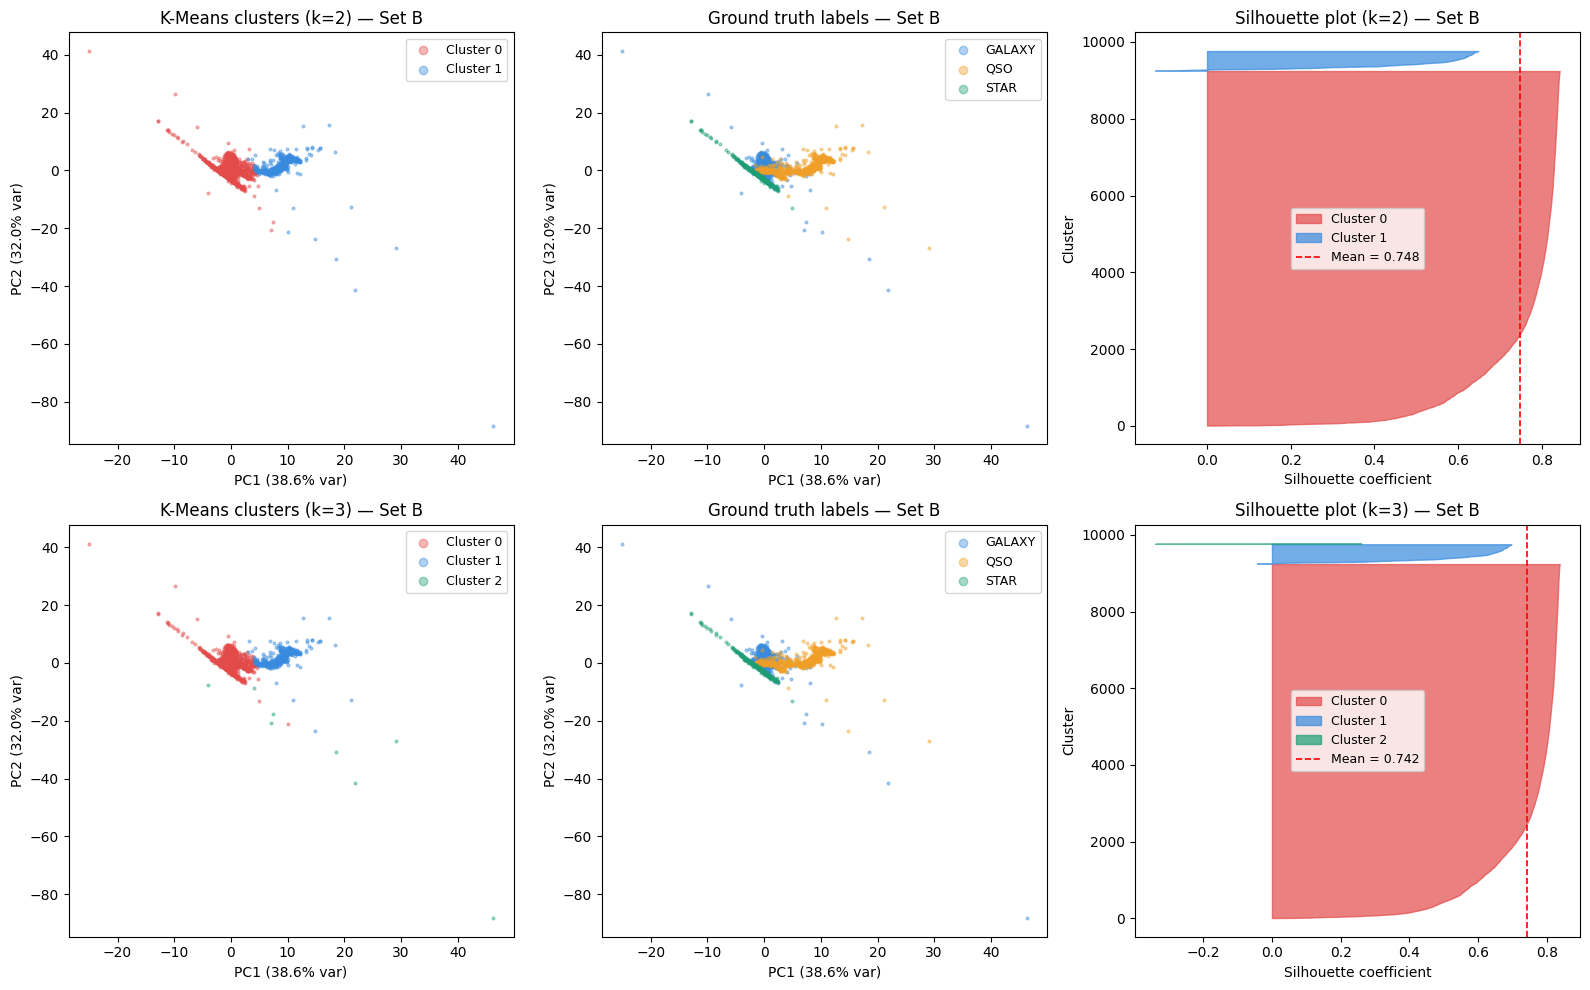

In [36]:
# ── 4. Plots: one row per k ───────────────────────────────────────────────────
fig, axes = plt.subplots(len(k_values), 3, figsize=(16, 5 * len(k_values)))

for row, k in enumerate(k_values):
    r      = results[k]
    labels = r["labels"]
    cols   = cluster_colors[:k]

    # Panel 1: cluster assignments
    ax = axes[row, 0]
    for i, cl in enumerate(np.unique(labels)):
        mask = labels == cl
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=cols[i], label=f"Cluster {cl}")
    ax.set_title(f"K-Means clusters (k={k}) — Set B")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

    # Panel 2: ground truth (same every row but useful for direct comparison)
    ax = axes[row, 1]
    for cls_name, col in class_colors.items():
        mask = y == cls_name
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=col, label=cls_name)
    ax.set_title(f"Ground truth labels — Set B")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

    # Panel 3: silhouette plot
    ax      = axes[row, 2]
    y_lower = 10
    for i, cl in enumerate(np.unique(labels)):
        cl_sil  = np.sort(r["sil_vals"][labels == cl])
        y_upper = y_lower + cl_sil.shape[0]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                         alpha=0.7, color=cols[i], label=f"Cluster {cl}")
        y_lower = y_upper + 10
    ax.axvline(x=r["sil"], color="red", linestyle="--", linewidth=1.2,
               label=f"Mean = {r['sil']:.3f}")
    ax.set_title(f"Silhouette plot (k={k}) — Set B")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

#### Interpretation of Set B's Results and Comparison against Set A

- Set B's PCA shows a long horizontal QSO tail along PC1 with everything else compressed near the origin, whereas Set A had a broad triangular fan. Set B's PC1 captures only 59.2% of variance vs Set A's 76.1%. This suggests the colour indices spread variance less efficiently, and the elongated geometry is fundamentally unfriendly to K-Means' spherical cluster assumption.
- Set B edges Set A marginally on silhouette and ARI at k=2, but Set A dominates every metric at k=3, most notably Calinski-Harabasz (12047 vs 5983) and ARI (0.322 vs 0.223).
- Both sets fail to isolate stars, but Set B's k=3 simply re-splits galaxies more evenly into two similar-purity subgroups, which is a less informative outcome. Set A's lower-purity second galaxy cluster (76.8%) at least reflects more mixing at a genuine boundary, which the higher ARI supports.

Set B's colour indices produce a cleaner geometric separation at k=2, but this comes at the cost of collapsing all remaining structure into an undifferentiated blob. Set A's broader feature space, despite being less QSO-focused, retains more discriminative geometry across the full dataset, making it the stronger feature set for any clustering solution beyond a simple two-class split.

#### Choice of K - Set D

In [38]:
# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------
SCALED_FEATURE_PATH = Path("../Set_D.csv")
RAW_LABEL_PATH = Path("../star-galaxy-quasar.csv")

FEATURE_COLS = ['u-g', 'g-r', 'r-i', 'i-z', 'u-z', 'g-z', 'uv_excess', 'r_i_sq', 'redshift_log']
TARGET_COL = "class"

# -------------------------------------------------------------------
# Load the team's scaled feature table
# -------------------------------------------------------------------
scaled_df = pd.read_csv(SCALED_FEATURE_PATH)

missing_features = [c for c in FEATURE_COLS if c not in scaled_df.columns]
if missing_features:
    raise ValueError(
        f"Missing expected feature columns in {SCALED_FEATURE_PATH}: {missing_features}"
    )

Set_D = scaled_df[FEATURE_COLS].copy()

if TARGET_COL in scaled_df.columns:
    y = scaled_df[TARGET_COL].copy()
else:
    raw_labels = pd.read_csv(RAW_LABEL_PATH, skiprows=1)
    if TARGET_COL not in raw_labels.columns:
        raise ValueError(f"Could not find '{TARGET_COL}' in {RAW_LABEL_PATH}")
    if len(raw_labels) != len(scaled_df):
        raise ValueError(
            "Scaled feature table and raw label table have different row counts. "
            "Please verify row alignment before proceeding."
        )
    y = raw_labels[TARGET_COL].copy()

print("Feature matrix shape:", Set_D.shape)
print("Feature columns:", FEATURE_COLS)
print("\nClass distribution:")
print(y.value_counts(dropna=False))
Set_D.head()

Feature matrix shape: (9744, 9)
Feature columns: ['u-g', 'g-r', 'r-i', 'i-z', 'u-z', 'g-z', 'uv_excess', 'r_i_sq', 'redshift_log']

Class distribution:
class
GALAXY    8434
QSO        685
STAR       625
Name: count, dtype: int64


,u-g,g-r,r-i,i-z,u-z,g-z,uv_excess,r_i_sq,redshift_log
0,0.282411,0.199434,0.172105,0.112554,0.191836,0.169022,0.396562,0.179567,-0.129219
1,0.082362,0.183747,0.894299,0.214554,0.158368,0.307230,-0.000841,1.040544,-0.423912
2,-0.312555,-0.067643,-0.071414,0.073737,-0.216620,-0.051381,-0.502631,-0.074656,-0.203070
3,0.397669,0.144856,0.245255,0.254769,0.253907,0.176858,0.707119,0.259488,-0.171899
4,-0.265413,-0.435137,-0.089880,-0.786944,-0.396206,-0.467156,0.067116,-0.093190,-0.273773


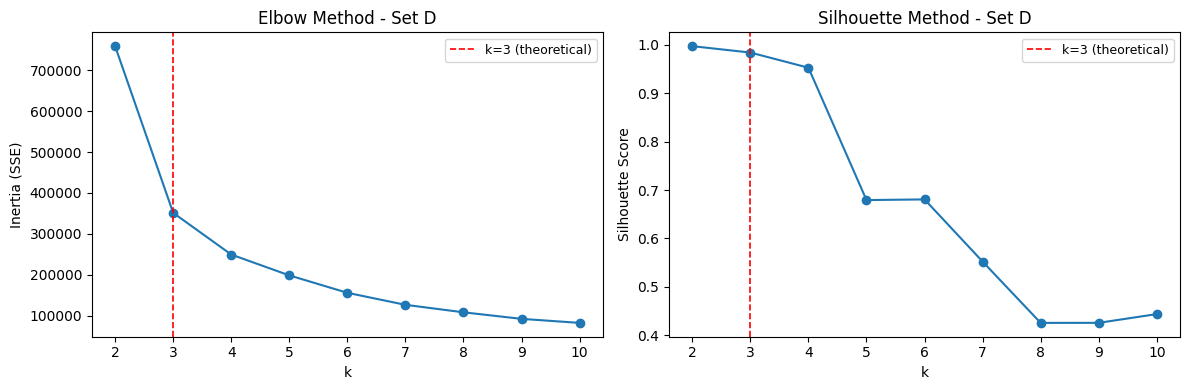

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Set_D)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(Set_D, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(k_range, inertias, marker='o')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow Method - Set D")
axes[0].legend(fontsize=9)

# Silhouette plot
axes[1].plot(k_range, silhouettes, marker='o')
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Method - Set D")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Elbow: 
- This is the clearest elbow seen across all sets. 

Silhouette:
- The near-flat silhouette from k=2 to k=4 means three and four clusters are nearly as well-separated as two. This suggests the feature engineering has created genuinely distinct regions in feature space for each physical class.

#### Cluster Stability for Optimal K: Set D

Clustering...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.
Labels saved.
Measuring stabilities...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.

staco shape: (900, 3)  (columns: stability, compactness, k)


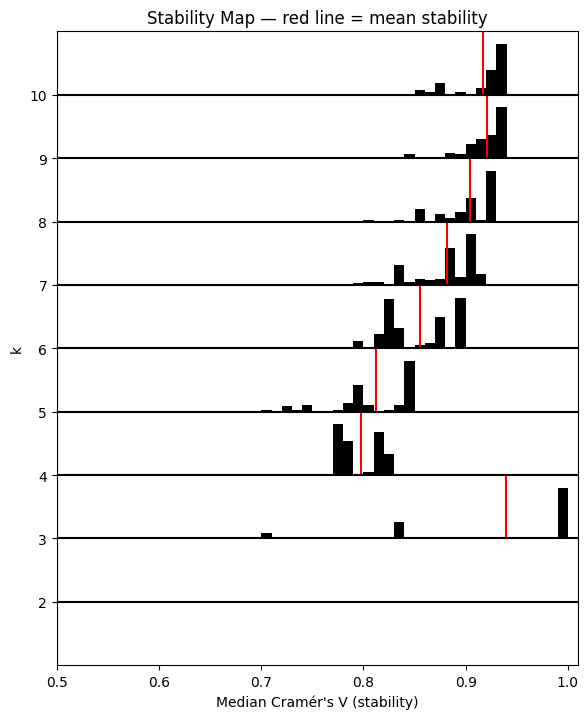

In [40]:
# Run Stacopy on data
k    = range(2, 11)  # candidate k values to evaluate
init = 100            # number of k-means runs per k (use 100 for final analysis)

data = np.array(Set_D)  # ensure numpy array

lbls_dict = {}  # store labels in memory instead of disk

if __name__ == '__main__':
    staco = STACO(data, k=k, init=init, save_lbls=True)  # let it save temporarily

    # Read all saved label files into memory, then delete them
    for ki in k:
        fname = f'lbls_k{ki}.txt'
        if os.path.exists(fname):
            lbls_dict[ki] = np.genfromtxt(fname, delimiter=',')
            os.remove(fname)  # delete after reading

    # Also clean up staco results file
    if os.path.exists('staco_results.txt'):
        staco = np.genfromtxt('staco_results.txt', delimiter=',')
        os.remove('staco_results.txt')

    print(f"\nstaco shape: {staco.shape}  (columns: stability, compactness, k)")

# Plot stability map
fig, ax = plt.subplots(figsize=(6, 0.7 * len(k) + 1))

for i in k:
    cvs = staco[staco[:, 2] == i, 0].reshape(-1, 1)

    hist, bins = np.histogram(cvs, bins=np.arange(0.0, 1.01, 0.01))
    hist = (hist.astype(float) / float(max(hist))) * 0.8

    ax.plot([0.0, 1.01], [i, i], c='k', ls='-', lw=1.5, zorder=3)
    ax.bar(bins[1:] - 0.005, hist, width=0.01, bottom=i, color='k')
    ax.plot([np.mean(cvs), np.mean(cvs)], [i, i + 1], 'r-', lw=1.5)

ax.set(
    yticks=list(k),
    xlim=(0.5, 1.01),
    ylim=(min(k) - 1, max(k) + 1),
    xlabel='Median Cramér\'s V (stability)',
    ylabel='k'
)
ax.set_title('Stability Map — red line = mean stability')
plt.tight_layout()
plt.show()

- In Sets A and B, k=2 was the most stable solution. In Set D, the runs for k=2 frequently disagree on the two-cluster assignment. This implies that k=2 is actually an unstable, degenerate split in Set D's feature space, despite its near-perfect silhouette score.
- k=3 is the most stable, suggesting three well-separated clusters, possibly due to the log redshift createing three genuinely distinct, tight clouds in feature space. 

#### K-Means Evaluation - Set D (K=2 to K=3)

In [42]:
# ── 0. Setup ──────────────────────────────────────────────────────────────────
le     = LabelEncoder()
y_true = le.fit_transform(y)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(Set_D)
ev   = pca.explained_variance_ratio_

class_colors    = {"GALAXY": "#378ADD", "QSO": "#EF9F27", "STAR": "#1D9E75"}
cluster_colors  = ["#E24B4A", "#378ADD", "#1D9E75", "#EF9F27"]
k_values        = [2, 3]

# ── 1. Fit, evaluate, and store results for each k ───────────────────────────
results = {}

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(Set_D)

    sil = silhouette_score(Set_D, labels)
    db  = davies_bouldin_score(Set_D, labels)
    ch  = calinski_harabasz_score(Set_D, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    ct          = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["true class"])
    ct.columns  = le.classes_
    sil_vals    = silhouette_samples(Set_D, labels)

    results[k] = dict(labels=labels, sil=sil, db=db, ch=ch,
                      inertia=km.inertia_, ari=ari, nmi=nmi,
                      ct=ct, sil_vals=sil_vals)

# ── 2. Summary metrics table ──────────────────────────────────────────────────
print(f"{'k':<4} {'Silhouette':>10} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Inertia':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 75)
for k in k_values:
    r = results[k]
    print(f"{k:<4} {r['sil']:>10.4f} {r['db']:>15.4f} {r['ch']:>12.2f} {r['inertia']:>12.2f} {r['ari']:>8.4f} {r['nmi']:>8.4f}")

# ── 3. Crosstab and per-cluster purity for each k ────────────────────────────
for k in k_values:
    r  = results[k]
    ct = r["ct"]
    print(f"\n{'='*50}")
    print(f"k = {k}  |  Cluster × True Class")
    print('='*50)
    print(ct.to_string())
    print()
    for cl in np.unique(r["labels"]):
        dominant       = ct.loc[cl].idxmax()
        cluster_purity = ct.loc[cl].max() / ct.loc[cl].sum()
        n              = (r["labels"] == cl).sum()
        print(f"  Cluster {cl} → {dominant:8s}  ({cluster_purity*100:.1f}% pure, n={n})")

k    Silhouette  Davies-Bouldin   Calinski-H      Inertia      ARI      NMI
---------------------------------------------------------------------------
2        0.9969          0.0020     33235.96    758834.17  -0.0002   0.0001
3        0.9837          0.3188     41524.99    351432.84   0.0003   0.0004

k = 2  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          8433  685   625
1             1    0     0

  Cluster 0 → GALAXY    (86.6% pure, n=9743)
  Cluster 1 → GALAXY    (100.0% pure, n=1)

k = 3  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          8429  684   625
1             1    0     0
2             4    1     0

  Cluster 0 → GALAXY    (86.6% pure, n=9738)
  Cluster 1 → GALAXY    (100.0% pure, n=1)
  Cluster 2 → GALAXY    (80.0% pure, n=5)


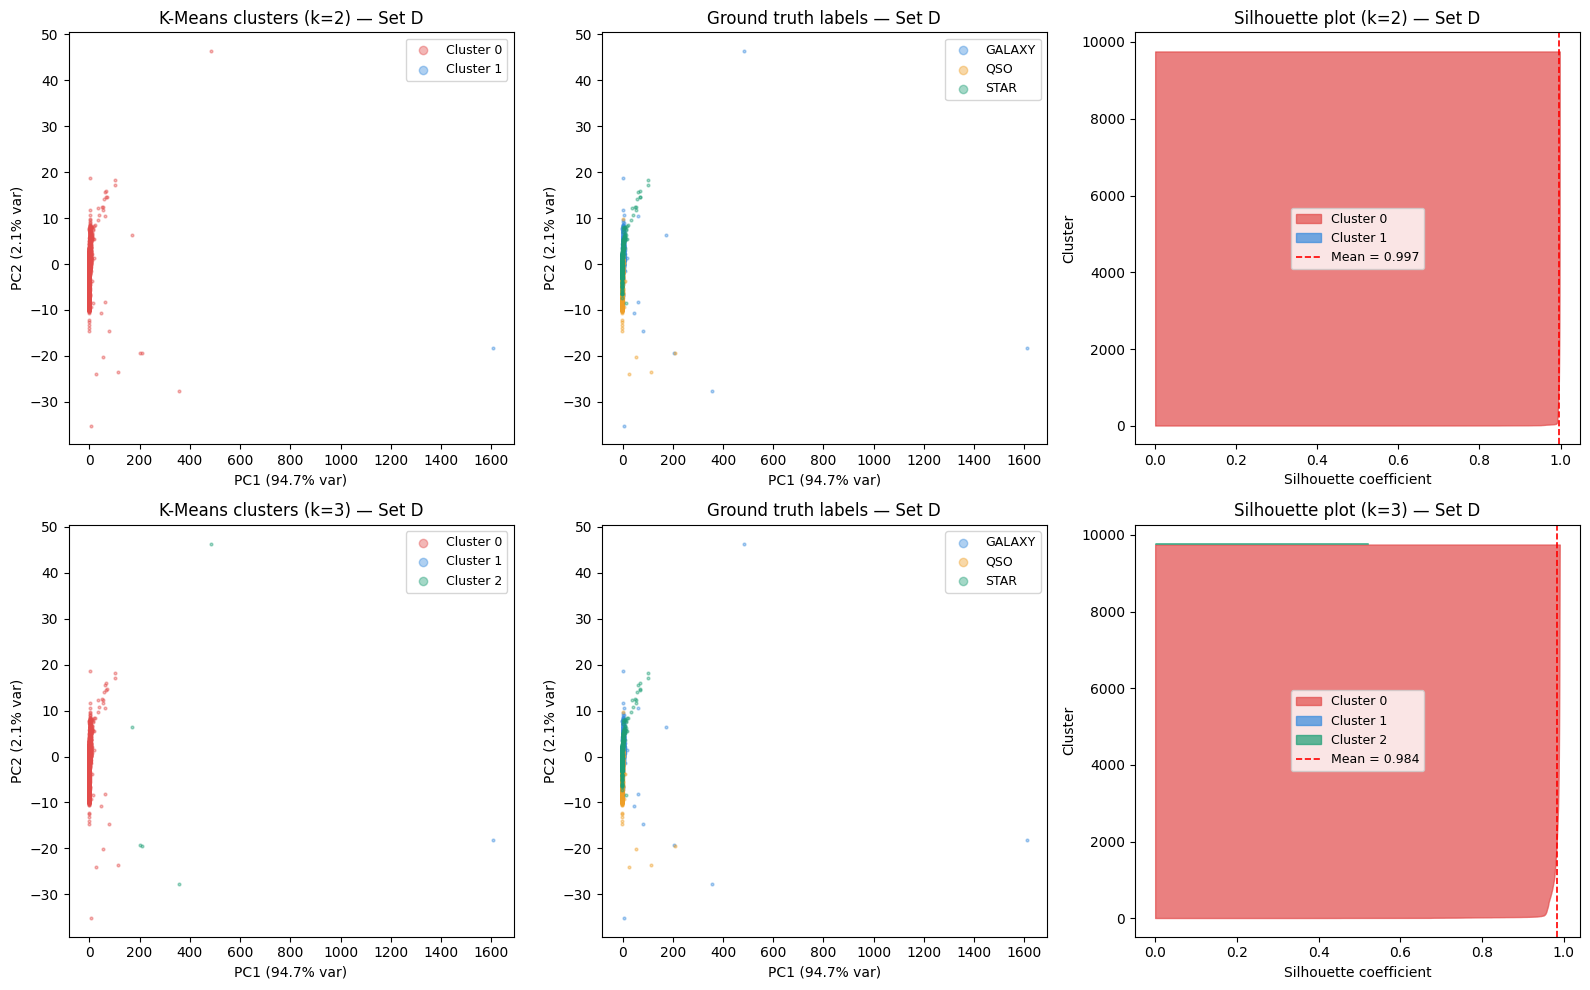

In [43]:
# ── 4. Plots: one row per k ───────────────────────────────────────────────────
fig, axes = plt.subplots(len(k_values), 3, figsize=(16, 5 * len(k_values)))

for row, k in enumerate(k_values):
    r      = results[k]
    labels = r["labels"]
    cols   = cluster_colors[:k]

    # Panel 1: cluster assignments
    ax = axes[row, 0]
    for i, cl in enumerate(np.unique(labels)):
        mask = labels == cl
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=cols[i], label=f"Cluster {cl}")
    ax.set_title(f"K-Means clusters (k={k}) — Set D")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

    # Panel 2: ground truth (same every row but useful for direct comparison)
    ax = axes[row, 1]
    for cls_name, col in class_colors.items():
        mask = y == cls_name
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=col, label=cls_name)
    ax.set_title(f"Ground truth labels — Set D")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

    # Panel 3: silhouette plot
    ax      = axes[row, 2]
    y_lower = 10
    for i, cl in enumerate(np.unique(labels)):
        cl_sil  = np.sort(r["sil_vals"][labels == cl])
        y_upper = y_lower + cl_sil.shape[0]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                         alpha=0.7, color=cols[i], label=f"Cluster {cl}")
        y_lower = y_upper + 10
    ax.axvline(x=r["sil"], color="red", linestyle="--", linewidth=1.2,
               label=f"Mean = {r['sil']:.3f}")
    ax.set_title(f"Silhouette plot (k={k}) — Set D")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

- The cluster crosstabs reveals underlying degeneracy. The root cause was identified as the (r-i)² term. Squaring the r-i colour difference introduced extreme outliers that, even after RobustScaler normalisation, dominated the Euclidean distance calculations.

#### Rerunning Set D with a 99th-percentile clip

In [38]:
X_scaled_array = prepared['D']['X_scaled']
columns = prepared['D']['columns']
original_index = prepared['D']['X_df'].index

df_scaled_D_modified = pd.DataFrame(X_scaled_array, columns=columns, index=original_index)

# Clip r_i_sq to 99th percentile to suppress extreme outliers post-scaling
cap = df_scaled_D_modified['r_i_sq'].quantile(0.99)
df_scaled_D_modified['r_i_sq'] = df_scaled_D_modified['r_i_sq'].clip(upper=cap)

display(df_scaled_D_modified.head())

,u-g,g-r,r-i,i-z,u-z,g-z,uv_excess,r_i_sq,redshift_log
0,0.282411,0.199434,0.172105,0.112554,0.191836,0.169022,0.396562,0.179567,-0.129219
1,0.082362,0.183747,0.894299,0.214554,0.158368,0.307230,-0.000841,1.040544,-0.423912
2,-0.312555,-0.067643,-0.071414,0.073737,-0.216620,-0.051381,-0.502631,-0.074656,-0.203070
3,0.397669,0.144856,0.245255,0.254769,0.253907,0.176858,0.707119,0.259488,-0.171899
4,-0.265413,-0.435137,-0.089880,-0.786944,-0.396206,-0.467156,0.067116,-0.093190,-0.273773


In [39]:
# ── 0. Setup ──────────────────────────────────────────────────────────────────
le     = LabelEncoder()
y_true = le.fit_transform(y)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(df_scaled_D_modified)
ev   = pca.explained_variance_ratio_

class_colors    = {"GALAXY": "#378ADD", "QSO": "#EF9F27", "STAR": "#1D9E75"}
cluster_colors  = ["#E24B4A", "#378ADD", "#1D9E75", "#EF9F27"]
k_values        = [2, 3]

# ── 1. Fit, evaluate, and store results for each k ───────────────────────────
results = {}

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(df_scaled_D_modified)

    sil = silhouette_score(df_scaled_D_modified, labels)
    db  = davies_bouldin_score(df_scaled_D_modified, labels)
    ch  = calinski_harabasz_score(df_scaled_D_modified, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    ct          = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["true class"])
    ct.columns  = le.classes_
    sil_vals    = silhouette_samples(df_scaled_D_modified, labels)

    results[k] = dict(labels=labels, sil=sil, db=db, ch=ch,
                      inertia=km.inertia_, ari=ari, nmi=nmi,
                      ct=ct, sil_vals=sil_vals)

# ── 2. Summary metrics table ──────────────────────────────────────────────────
print(f"{'k':<4} {'Silhouette':>10} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Inertia':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 75)
for k in k_values:
    r = results[k]
    print(f"{k:<4} {r['sil']:>10.4f} {r['db']:>15.4f} {r['ch']:>12.2f} {r['inertia']:>12.2f} {r['ari']:>8.4f} {r['nmi']:>8.4f}")

# ── 3. Crosstab and per-cluster purity for each k ────────────────────────────
for k in k_values:
    r  = results[k]
    ct = r["ct"]
    print(f"\n{'='*50}")
    print(f"k = {k}  |  Cluster × True Class")
    print('='*50)
    print(ct.to_string())
    print()
    for cl in np.unique(r["labels"]):
        dominant       = ct.loc[cl].idxmax()
        cluster_purity = ct.loc[cl].max() / ct.loc[cl].sum()
        n              = (r["labels"] == cl).sum()
        print(f"  Cluster {cl} → {dominant:8s}  ({cluster_purity*100:.1f}% pure, n={n})")

k    Silhouette  Davies-Bouldin   Calinski-H      Inertia      ARI      NMI
---------------------------------------------------------------------------
2        0.6891          0.6543      3318.57    153482.23   0.4955   0.4514
3        0.5550          0.9362      3317.85    122391.07   0.2629   0.2922

k = 2  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          8412  170   625
1            22  515     0

  Cluster 0 → GALAXY    (91.4% pure, n=9207)
  Cluster 1 → QSO       (95.9% pure, n=537)

k = 3  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          7255  166   548
1          1161   12    77
2            18  507     0

  Cluster 0 → GALAXY    (91.0% pure, n=7969)
  Cluster 1 → GALAXY    (92.9% pure, n=1250)
  Cluster 2 → QSO       (96.6% pure, n=525)


- Applying a 99th-percentile clip to the (r-i)² feature post-scaling resolved the degeneracy and produced non-degenerate cluster assignments. However, the corrected Set D results converged closely to those of Sets A and B, offering no meaningful improvement in star/galaxy separation. 
- This is consistent with the observation that log-transformed redshift dominates the feature space, rendering the accompanying colour engineering largely redundant. The fundamental limitation identified in Sets A and B that stars and galaxies occupy overlapping regions in photometric feature space and cannot be reliably separated by K-Means persists in Set D.

#### Photometry-only run ( Set A)

In [40]:
X_scaled_array = prepared['A']['X_scaled']
columns = prepared['A']['columns']
original_index = prepared['A']['X_df'].index
# Create the full scaled DataFrame
df_scaled_A = pd.DataFrame(X_scaled_array, columns=columns, index=original_index)
df_scaled_A = df_scaled_A.drop(columns=['redshift'])
display(df_scaled_A.head())

,u,g,r,i,z
0,0.061603,-0.286684,-0.509810,-0.543561,-0.538142
1,-1.050913,-1.564148,-1.981714,-2.107880,-2.003299
2,0.076207,0.132569,0.103745,0.100900,0.064999
3,0.463989,0.146469,0.017982,-0.026611,-0.079561
4,-0.002486,0.000927,0.127445,0.126993,0.214433


In [41]:
# ── 0. Setup ──────────────────────────────────────────────────────────────────
le     = LabelEncoder()
y_true = le.fit_transform(y)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(df_scaled_A)
ev   = pca.explained_variance_ratio_

class_colors    = {"GALAXY": "#378ADD", "QSO": "#EF9F27", "STAR": "#1D9E75"}
cluster_colors  = ["#E24B4A", "#378ADD", "#1D9E75", "#EF9F27"]
k_values        = [2, 3]

# ── 1. Fit, evaluate, and store results for each k ───────────────────────────
results = {}

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(df_scaled_A)

    sil = silhouette_score(df_scaled_A, labels)
    db  = davies_bouldin_score(df_scaled_A, labels)
    ch  = calinski_harabasz_score(df_scaled_A, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    ct          = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["true class"])
    ct.columns  = le.classes_
    sil_vals    = silhouette_samples(df_scaled_A, labels)

    results[k] = dict(labels=labels, sil=sil, db=db, ch=ch,
                      inertia=km.inertia_, ari=ari, nmi=nmi,
                      ct=ct, sil_vals=sil_vals)

# ── 2. Summary metrics table ──────────────────────────────────────────────────
print(f"{'k':<4} {'Silhouette':>10} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Inertia':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 75)
for k in k_values:
    r = results[k]
    print(f"{k:<4} {r['sil']:>10.4f} {r['db']:>15.4f} {r['ch']:>12.2f} {r['inertia']:>12.2f} {r['ari']:>8.4f} {r['nmi']:>8.4f}")

# ── 3. Crosstab and per-cluster purity for each k ────────────────────────────
for k in k_values:
    r  = results[k]
    ct = r["ct"]
    print(f"\n{'='*50}")
    print(f"k = {k}  |  Cluster × True Class")
    print('='*50)
    print(ct.to_string())
    print()
    for cl in np.unique(r["labels"]):
        dominant       = ct.loc[cl].idxmax()
        cluster_purity = ct.loc[cl].max() / ct.loc[cl].sum()
        n              = (r["labels"] == cl).sum()
        print(f"  Cluster {cl} → {dominant:8s}  ({cluster_purity*100:.1f}% pure, n={n})")

k    Silhouette  Davies-Bouldin   Calinski-H      Inertia      ARI      NMI
---------------------------------------------------------------------------
2        0.5342          0.8019      8610.65     31069.08   0.3032   0.1556
3        0.4795          0.7594     10401.43     18666.33   0.1192   0.0920

k = 2  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          7248  132   371
1          1186  553   254

  Cluster 0 → GALAXY    (93.5% pure, n=7751)
  Cluster 1 → GALAXY    (59.5% pure, n=1993)

k = 3  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          1908   17   139
1          1032  486   216
2          5494  182   270

  Cluster 0 → GALAXY    (92.4% pure, n=2064)
  Cluster 1 → GALAXY    (59.5% pure, n=1734)
  Cluster 2 → GALAXY    (92.4% pure, n=5946)


#### Photometry-only run (Set B)

In [42]:
X_scaled_array = prepared['B']['X_scaled']
columns = prepared['B']['columns']
original_index = prepared['B']['X_df'].index
# Create the full scaled DataFrame
df_scaled_B = pd.DataFrame(X_scaled_array, columns=columns, index=original_index)
df_scaled_B = df_scaled_B.drop(columns=['redshift'])
display(df_scaled_B.head())

,u-g,g-r,r-i,i-z
0,0.282411,0.199434,0.172105,0.112554
1,0.082362,0.183747,0.894299,0.214554
2,-0.312555,-0.067643,-0.071414,0.073737
3,0.397669,0.144856,0.245255,0.254769
4,-0.265413,-0.435137,-0.089880,-0.786944


In [43]:
# ── 0. Setup ──────────────────────────────────────────────────────────────────
le     = LabelEncoder()
y_true = le.fit_transform(y)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(df_scaled_B)
ev   = pca.explained_variance_ratio_

class_colors    = {"GALAXY": "#378ADD", "QSO": "#EF9F27", "STAR": "#1D9E75"}
cluster_colors  = ["#E24B4A", "#378ADD", "#1D9E75", "#EF9F27"]
k_values        = [2, 3]

# ── 1. Fit, evaluate, and store results for each k ───────────────────────────
results = {}

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(df_scaled_B)

    sil = silhouette_score(df_scaled_B, labels)
    db  = davies_bouldin_score(df_scaled_B, labels)
    ch  = calinski_harabasz_score(df_scaled_B, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    ct          = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["true class"])
    ct.columns  = le.classes_
    sil_vals    = silhouette_samples(df_scaled_B, labels)

    results[k] = dict(labels=labels, sil=sil, db=db, ch=ch,
                      inertia=km.inertia_, ari=ari, nmi=nmi,
                      ct=ct, sil_vals=sil_vals)

# ── 2. Summary metrics table ──────────────────────────────────────────────────
print(f"{'k':<4} {'Silhouette':>10} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Inertia':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 75)
for k in k_values:
    r = results[k]
    print(f"{k:<4} {r['sil']:>10.4f} {r['db']:>15.4f} {r['ch']:>12.2f} {r['inertia']:>12.2f} {r['ari']:>8.4f} {r['nmi']:>8.4f}")

# ── 3. Crosstab and per-cluster purity for each k ────────────────────────────
for k in k_values:
    r  = results[k]
    ct = r["ct"]
    print(f"\n{'='*50}")
    print(f"k = {k}  |  Cluster × True Class")
    print('='*50)
    print(ct.to_string())
    print()
    for cl in np.unique(r["labels"]):
        dominant       = ct.loc[cl].idxmax()
        cluster_purity = ct.loc[cl].max() / ct.loc[cl].sum()
        n              = (r["labels"] == cl).sum()
        print(f"  Cluster {cl} → {dominant:8s}  ({cluster_purity*100:.1f}% pure, n={n})")

k    Silhouette  Davies-Bouldin   Calinski-H      Inertia      ARI      NMI
---------------------------------------------------------------------------
2        0.4724          0.8537      2875.30     71391.67   0.2795   0.1876
3        0.4716          0.7799      3792.90     51982.00   0.2699   0.1844

k = 2  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          6659   75   139
1          1775  610   486

  Cluster 0 → GALAXY    (96.9% pure, n=6873)
  Cluster 1 → GALAXY    (61.8% pure, n=2871)

k = 3  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          6596   71   135
1             6    2     0
2          1832  612   490

  Cluster 0 → GALAXY    (97.0% pure, n=6802)
  Cluster 1 → GALAXY    (75.0% pure, n=8)
  Cluster 2 → GALAXY    (62.4% pure, n=2934)
